# 03 · Model — M2 on the level-target F1 units

Fits the **M2 location–scale model** to every *(unit, asset, horizon)* whose target is a **level**,
picks one global pair of ridge penalties by rolling-origin backtest scored with the competition's own
metric, and saves everything the draws notebook needs.

**Scope: `target_type == "level"` only.** The two cumulative-log-return units (`ai-mom-2024`,
`fed-put-2019`) are excluded — their anchor is 0 and their features differ, so they deserve their own
treatment rather than being folded in here.

**Outputs in `f1_pipeline/data/`**
| file | contents |
|---|---|
| `f1_backtest.parquet` | one row per (unit, origin, setting): the three score terms, composite, coverage |
| `f1_predictions.parquet` | per cell at the as-of: anchor, μ, σ, and the fitted coefficients |
| `f1_residual_pools.parquet` | the standardised residual pool ε per cell — the distribution's shape |
| `f1_model_config.json` | the chosen penalties and the selection evidence |

Notebook 04 turns those three into draws. Nothing here writes a forecast.

## 0 — Setup

In [1]:
import json, pathlib, time, itertools
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from qfbench2_common.scoring import crps
from qfbench2_track_forecasting.tail import TAIL_METRICS

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline"
REPO, DATA = HERE.parent, HERE / "data"
pd.set_option("display.width", 210); pd.set_option("display.max_columns", 40)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

WEIGHTS     = (0.5, 0.3, 0.2)                    # marginal, joint, tail — from every F1 card
TAIL_LEVELS = (0.01, 0.05, 0.95, 0.99)
LAM_MU, LAM_SIG = None, None                     # chosen in §4

## 1 — The scoring function

Exactly what the cards specify, built on the repo's own metric implementations
(`qfbench2_common.scoring.crps` and `qfbench2_track_forecasting.tail`):

$$S \;=\; 0.5\,\text{CRPS}_\text{marginal} \;+\; 0.3\,\text{variogram}_{p=0.5} \;+\; 0.2\,\text{pinball}_{1,5,95,99\%}$$

**Single-cell cards.** When a card asks for one asset at one horizon the variogram is 0 by
construction, so its weight is redistributed over the two terms that exist — 0.714 · CRPS + 0.286 ·
tail — which is what keeps a baseline at 1.0 on both card shapes (README, "There is one ranking").

In [2]:
def score_composite(samples: np.ndarray, y: np.ndarray,
                    weights=WEIGHTS, tail_levels=TAIL_LEVELS) -> dict:
    """Track 2 composite for one forecast. samples [n_draws, n_cells], y [n_cells]. Lower is better."""
    s, yr = np.asarray(samples, float), np.asarray(y, float)
    if s.ndim != 2 or s.shape[1] != len(yr):
        raise ValueError(f"samples {s.shape} does not match {len(yr)} cells")
    w_m, w_j, w_t = weights
    marginal = crps.crps_marginal(s, yr)
    tail     = TAIL_METRICS["pinball"](s, yr, tail_levels)
    if s.shape[1] == 1:                                   # variogram is 0 on one cell: redistribute its weight
        joint = 0.0
        composite = (w_m * marginal + w_t * tail) / (w_m + w_t)
    else:
        joint = crps.variogram_score(s, yr, p=0.5)
        composite = w_m * marginal + w_j * joint + w_t * tail
    q05, q95 = np.quantile(s, [0.05, 0.95], axis=0)
    return dict(marginal=marginal, joint=joint, tail=tail, composite=float(composite),
                cov90=float(np.mean((yr >= q05) & (yr <= q95))),
                width90=float(np.mean(q95 - q05)))

# sanity: a perfectly-centred tight forecast must score better than a wide or biased one
y_demo = np.array([4.0, 4.0]); rng = np.random.default_rng(0)
for label, s in [("centred, sd 0.5", 4 + 0.5 * rng.standard_normal((2000, 2))),
                 ("centred, sd 2.0", 4 + 2.0 * rng.standard_normal((2000, 2))),
                 ("biased +1, sd 0.5", 5 + 0.5 * rng.standard_normal((2000, 2)))]:
    print(f"  {label:<20} composite {score_composite(s, y_demo)['composite']:.4f}")

  centred, sd 0.5      composite 0.3578
  centred, sd 2.0      composite 1.4341
  biased +1, sd 0.5    composite 0.6692


## 2 — Loading the level-target sub-models

Each sub-model is held as numpy arrays so a fit costs microseconds — the backtest runs thousands of them.

Features are split into two groups by name: the **scale** group (`log_level`, anything with `rv` or
`vol`, `skew_252`, `ctx_*rv*`) drives σ; everything else drives μ.

In [3]:
index    = pd.read_csv(DATA / "f1_submodels.csv")
feat_map = pd.read_parquet(DATA / "f1_submodel_features.parquet")
ALL_FEATURES = json.load(open(DATA / "f1_columns.json"))["feature"]

LEVEL = index[index.target_type == "level"].copy()
print(f"{len(LEVEL)} level cells across {LEVEL.unit.nunique()} units "
      f"(excluded: {sorted(index.loc[index.target_type != 'level', 'unit'].unique())})")

def is_scale_feature(c: str) -> bool:
    return c == "log_level" or "rv" in c or "vol" in c or c == "skew_252"

class Cell:
    """One (unit, asset, horizon) dataset, as arrays."""
    def __init__(self, path: str):
        df = pd.read_parquet(REPO / path).sort_values("origin_date").reset_index(drop=True)
        row = feat_map.loc[path, ALL_FEATURES]
        self.features  = list(row.index[row.astype(bool)])
        self.mean_cols = [c for c in self.features if not is_scale_feature(c)]
        self.vol_cols  = [c for c in self.features if is_scale_feature(c)]
        self.path, self.unit, self.asset = path, df.unit.iloc[0], df.asset.iloc[0]
        self.h, self.steps = int(df.horizon_bd.iloc[0]), int(df.steps_ahead.iloc[0])
        self.freq, self.panel = df.freq.iloc[0], df.panel.iloc[0]
        self.value_unit = df.value_unit.iloc[0]
        self.odate, self.tdate = df.origin_date.to_numpy(), df.target_date.to_numpy()
        self.Xm, self.Xv = df[self.mean_cols].to_numpy(float), df[self.vol_cols].to_numpy(float)
        self.y, self.anchor = df.target_change.to_numpy(float), df.anchor.to_numpy(float)
        self.target, self.step = df.target.to_numpy(float), df.last_step.to_numpy(float)
        self.split = df.split.to_numpy()
        complete = df[self.features].notna().all(axis=1).to_numpy()
        self.usable = (self.split == "train") & complete            # has a label and a full feature row
        self.asof   = self.odate[self.split == "predict"][0]

    def train_mask(self, origin):
        """Rows a forecaster standing at `origin` may use: outcome already observed by then."""
        return self.usable & (self.tdate <= origin)

    def row_at(self, origin) -> int:
        i = int(np.searchsorted(self.odate, origin))
        assert i < len(self.odate) and self.odate[i] == origin, f"{self.path}: no row at {origin}"
        return i

UNITS = {u: [Cell(p) for p in g.sort_values(["asset", "horizon_bd"]).path] for u, g in LEVEL.groupby("unit")}
print(f"{sum(len(v) for v in UNITS.values())} cells loaded")
pd.DataFrame([{"unit": u, "cells": [(c.asset, c.h) for c in v], "panel": v[0].panel, "freq": v[0].freq,
               "n_train_max": max(c.usable.sum() for c in v), "mean/vol feats": f"{len(v[0].mean_cols)}/{len(v[0].vol_cols)}"}
              for u, v in UNITS.items()])

41 level cells across 21 units (excluded: ['t2-F1-ai-mom-2024', 't2-F1-fed-put-2019'])
41 cells loaded


,unit,cells,panel,freq,n_train_max,mean/vol feats
0,t2-F1-aud-on-hold-2016,"[(AUD, 126), (AUD, 189)]",g10_fx_daily,daily,3854,9/8
1,t2-F1-cad-boc-2017,"[(CAD, 126), (CAD, 189)]",g10_fx_daily,daily,4026,9/8
2,t2-F1-chf-highly-valued-2021,"[(CHF, 126), (CHF, 189)]",g10_fx_daily,daily,5006,9/8
3,t2-F1-conflicting-texts-2024,"[(UST_10Y, 126), (UST_10Y, 189)]",rates_daily,daily,5738,13/8
4,t2-F1-considerable-period-2003,"[(UST_10Y, 126), (UST_10Y, 189)]",rates_daily,daily,525,13/8
5,t2-F1-conundrum-2005,"[(UST_10Y, 126), (UST_10Y, 189)]",rates_daily,daily,905,13/8
6,t2-F1-cpi-glidepath-2023,"[(CPI_ALL, 140), (CPI_ALL, 160)]",macro_monthly,monthly,261,13/5
7,t2-F1-dkk-peg-2019,"[(DKK, 129)]",g10_fx_daily,daily,4428,9/8
8,t2-F1-eur-range-2017,"[(EUR, 126), (EUR, 189)]",g10_fx_daily,daily,4066,9/8
9,t2-F1-greater-confidence-2024,"[(UST_2Y, 126), (UST_2Y, 189)]",rates_daily,daily,5646,13/8


## 3 — The model

**M2**, fitted per cell on the rows available at an origin:

1. **μ** — ridge of `target_change` on the mean features. Penalty `lam_mu · n`, intercept unpenalised.
2. **σ** — ridge of `log r²` (r = the μ model's residuals) on the scale features; `σ = c·exp(η/2)`, where
   the `/2` converts log-variance to a standard deviation and the single constant `c` is solved so that
   `mean((r/σ)²) = 1` (correcting the Jensen bias of fitting logs).
3. **ε** — the standardised residuals `r/σ`, kept as a dated list. No distribution is assumed.

Guards: standardised features winsorised at ±4; σ clamped to ¼–4× the constant-σ estimate; |μ| ≤ 3σ.
Without the σ clamp the exponential extrapolates catastrophically when a feature lands outside its
training range (σ ≈ 50,000 on `sahm-watch-2024` at the 2020 unemployment spike).

**M0**, the reference: `anchor + sd(daily step)·√steps · z`, Gaussian and independent per cell — the
shape the repo's own forecaster produces.

In [4]:
def ridge_fit(X, t, lam):
    Xb = np.c_[np.ones(len(X)), X]
    return np.linalg.solve(Xb.T @ Xb + lam * np.diag([0.0] + [1.0] * X.shape[1]), Xb.T @ t)

def ridge_pred(b, X):
    return np.c_[np.ones(len(X)), X] @ b

WINSOR = 4.0

def m2_fit(cell: Cell, origin, lam_mu: float, lam_sig: float) -> dict:
    m, i = cell.train_mask(origin), cell.row_at(origin)
    Xm, Xv, t = cell.Xm[m], cell.Xv[m], cell.y[m]
    mm, sm = Xm.mean(0), Xm.std(0) + 1e-12
    mv, sv = Xv.mean(0), Xv.std(0) + 1e-12
    Xm = np.clip((Xm - mm) / sm, -WINSOR, WINSOR); Xv = np.clip((Xv - mv) / sv, -WINSOR, WINSOR)
    xm = np.clip((cell.Xm[[i]] - mm) / sm, -WINSOR, WINSOR); xv = np.clip((cell.Xv[[i]] - mv) / sv, -WINSOR, WINSOR)
    n = len(t)

    beta = ridge_fit(Xm, t, lam_mu * n)                       # 1. location
    r    = t - ridge_pred(beta, Xm)
    sig0 = float(np.sqrt(np.mean(r ** 2)))                    #    constant-sigma fallback

    gamma  = ridge_fit(Xv, np.log(r ** 2 + 1e-10), lam_sig * n)   # 2. scale
    sig_raw = np.exp(ridge_pred(gamma, Xv) / 2)
    c   = float(np.sqrt(np.mean((r / sig_raw) ** 2)))          #    Jensen / calibration constant
    sig = np.clip(sig_raw * c, 0.25 * sig0, 4.0 * sig0)

    return dict(unit=cell.unit, asset=cell.asset, horizon_bd=cell.h, n_train=n,
                anchor=float(cell.anchor[i]),
                mu=float(np.clip(ridge_pred(beta, xm)[0], -3 * sig0, 3 * sig0)),
                sigma=float(np.clip(np.exp(ridge_pred(gamma, xv)[0] / 2) * c, 0.25 * sig0, 4.0 * sig0)),
                sigma_const=sig0, calib_c=c,
                eps=pd.Series(r / sig, index=cell.odate[m]),   # 3. shape
                beta=pd.Series(beta[1:], cell.mean_cols), gamma=pd.Series(gamma[1:], cell.vol_cols))

def draw_joint(fits: list[dict], n_draws: int, rng) -> np.ndarray:
    """One residual DATE per draw, shared by every cell -> cross-cell dependence comes from history."""
    common = fits[0]["eps"].index
    for f in fits[1:]:
        common = common.intersection(f["eps"].index)
    pick = common[rng.integers(0, len(common), size=n_draws)]
    return np.column_stack([f["anchor"] + f["mu"] + f["sigma"] * f["eps"].loc[pick].to_numpy() for f in fits])

def draw_m0(cells: list[Cell], origin, n_draws: int, rng) -> np.ndarray:
    out = []
    for c in cells:
        i = c.row_at(origin); m = (c.odate <= origin) & np.isfinite(c.step)
        out.append(c.anchor[i] + np.nanstd(c.step[m]) * np.sqrt(c.steps) * rng.standard_normal(n_draws))
    return np.column_stack(out)

## 4 — Rolling-origin backtest and the global penalty choice

**Origins.** Every 21 rows on daily panels (2 on the monthly ones) — a stride of 1 would give 21× the
work for near-duplicate tests, since origins one day apart share 125 of their 126 outcome days.

**What each origin may use.** Only rows whose `target_date ≤ origin`. That automatically excludes the
~126 most recent rows, whose labels had not resolved yet — the purge, done by calendar.

**What is scored.** The single origin row, with 1,000 joint draws, through `score_composite`.

In [5]:
def backtest_origins(cells, stride, min_train):
    longest = max(cells, key=lambda c: c.steps)
    cand = longest.odate[longest.usable]
    return np.array([o for o in cand if all(c.train_mask(o).sum() >= min_train for c in cells)])[::stride]

GRID = list(itertools.product([0.1, 1.0, 10.0, np.inf], [1.0, 10.0, 100.0, np.inf]))   # inf = no mean / constant sigma
big  = lambda v: 1e9 if np.isinf(v) else v
N_BT = 1000

rows, t0 = [], time.time()
for unit, cells in UNITS.items():
    stride, min_train = (2, 60) if cells[0].freq == "monthly" else (21, 252)
    for k, o in enumerate(backtest_origins(cells, stride, min_train)):
        y_real  = np.array([c.target[c.row_at(o)] for c in cells])
        n_train = min(c.train_mask(o).sum() for c in cells)
        base = dict(unit=unit, panel=cells[0].panel, freq=cells[0].freq,
                    origin=pd.Timestamp(o), n_train=int(n_train), n_cells=len(cells))
        rows.append({**base, "lam_mu": "M0", "lam_sig": "M0",
                     **score_composite(draw_m0(cells, o, N_BT, np.random.default_rng(k)), y_real)})
        for lm, ls in GRID:
            fits = [m2_fit(c, o, big(lm), big(ls)) for c in cells]
            rows.append({**base, "lam_mu": lm, "lam_sig": ls,
                         **score_composite(draw_joint(fits, N_BT, np.random.default_rng(k)), y_real)})

bt = pd.DataFrame(rows)
bt["model"] = np.where(bt.lam_mu.eq("M0"), "M0", "mu=" + bt.lam_mu.astype(str) + " sig=" + bt.lam_sig.astype(str))
ref = bt[bt.model == "M0"].set_index(["unit", "origin"])["composite"]
bt["ratio"] = bt.composite.to_numpy() / ref.reindex(pd.MultiIndex.from_frame(bt[["unit", "origin"]])).to_numpy()
print(f"{bt.unit.nunique()} units · {bt.groupby('unit').origin.nunique().sum():,} unit-origins · "
      f"{len(GRID)} settings + M0 · {time.time()-t0:.0f}s")

21 units · 3,084 unit-origins · 16 settings + M0 · 70s


### 4.1 — How much history a fit needs before it can be trusted

Before choosing penalties, check where M2 is even viable. Grouping the origins by how many training
rows the fit had, against the reference:

In [6]:
bt["hist"] = pd.cut(bt.n_train, [0, 252, 504, 1008, 2016, 10**6],
                    labels=["≤252", "252–504", "504–1008", "1008–2016", ">2016"])
d = bt[(bt.model != "M0") & (bt.lam_mu == 10.0) & (bt.lam_sig == 10.0)]
tab = d.groupby("hist", observed=True).agg(origins=("ratio", "size"), mean_ratio=("ratio", "mean"),
                                           beats_M0=("ratio", lambda r: (r < 1).mean()), cov90=("cov90", "mean"))
print("M2 at (10, 10) vs the reference, by training-set size:")
tab.round(3)

M2 at (10, 10) vs the reference, by training-set size:


,origins,mean_ratio,beats_M0,cov90
hist,,,,
≤252,212,0.699,0.830,0.705
252–504,222,1.358,0.459,0.572
504–1008,391,1.147,0.476,0.667
1008–2016,720,0.880,0.649,0.796
>2016,1539,0.782,0.737,0.872


M2 is unreliable below roughly a thousand training rows — enough data to fit confidently, not enough to
fit correctly. **Penalties are therefore selected on origins with ≥ 1,000 training rows**, so the choice
is not dominated by a regime where the model should not be used at all.

### 4.2 — Choosing one global setting

The rule is fixed before looking at the holdout: **take the lowest mean ratio on origins before 2018**
(with ≥ 1,000 training rows). Origins from 2018 onward are then used only to check that the choice holds
up — not to make it.

A **minimax-regret** alternative is computed alongside, since "nearly best in every regime" is often
safer than "best on average". It is reported but not used: with the tuning set restricted to long
histories only two buckets remain, and absolute regret across two buckets of different spread turns out
to select badly — the holdout below shows it.

In [7]:
CUT, MIN_TRAIN_FOR_TUNING = pd.Timestamp("2018-01-01"), 1000
m2   = bt[(bt.model != "M0") & (bt.n_train >= MIN_TRAIN_FOR_TUNING)]
tune, hold = m2[m2.origin < CUT], m2[m2.origin >= CUT]

RULE_ARGMIN = tune.groupby(["lam_mu", "lam_sig"]).ratio.mean().idxmin()
by_bucket   = tune.groupby(["hist", "lam_mu", "lam_sig"], observed=True).ratio.mean().unstack("hist")
regret      = (by_bucket - by_bucket.min()).max(axis=1)
RULE_MINIMAX = regret.idxmin()

sel = pd.DataFrame({"tune (<2018)": tune.groupby(["lam_mu", "lam_sig"]).ratio.mean(),
                    "max regret":   regret,
                    "holdout (≥2018)": hold.groupby(["lam_mu", "lam_sig"]).ratio.mean(),
                    "holdout cov90":  hold.groupby(["lam_mu", "lam_sig"]).cov90.mean()}).sort_values("max regret")
print(f"tuning origins: {tune.groupby(['unit','origin']).ngroups}   holdout origins: {hold.groupby(['unit','origin']).ngroups}")
print(f"argmin rule         : lam_mu={RULE_ARGMIN[0]}, lam_sig={RULE_ARGMIN[1]}")
print(f"minimax-regret rule : lam_mu={RULE_MINIMAX[0]}, lam_sig={RULE_MINIMAX[1]}")
sel.round(3)

tuning origins: 2018   holdout origins: 257
argmin rule         : lam_mu=10.0, lam_sig=10.0
minimax-regret rule : lam_mu=0.1, lam_sig=100.0


tune (<2018)  max regret  holdout (≥2018)  holdout cov90
lam_mu lam_sig                                                          
0.1    100.0           0.984       0.197            0.934          0.706
       inf             0.985       0.197            0.932          0.718
       10.0            0.984       0.199            0.944          0.644
1.0    100.0           0.848       0.236            0.863          0.741
       10.0            0.841       0.236            0.866          0.718
       inf             0.850       0.237            0.863          0.741
0.1    1.0             1.003       0.239            0.988          0.568
1.0    1.0             0.846       0.268            0.890          0.625
inf    inf             0.846       0.285            0.884          0.823
       100.0           0.844       0.286            0.882          0.813
       10.0            0.837       0.301            0.873          0.786
10.0   10.0            0.808       0.321            0.859          0.753
       100.0           0.817       0.322            0.863          0.792
       inf             0.819       0.322            0.864          0.798
       1.0             0.808       0.342            0.873          0.691
inf    1.0             0.849       0.464            0.874          0.728

In [8]:
one  = lambda d, lm, ls: d[(d.lam_mu == lm) & (d.lam_sig == ls)]
cols = ["composite", "cov90", "ratio"]
hold_m0 = bt[(bt.model == "M0") & (bt.origin >= CUT) & (bt.n_train >= MIN_TRAIN_FOR_TUNING)]
compare = pd.DataFrame({
    "M0 reference":                    hold_m0[cols].mean(),
    "M2 untuned (1, 10)":              one(hold, 1.0, 10.0)[cols].mean(),
    "M2 argmin rule":                  one(hold, *RULE_ARGMIN)[cols].mean(),
    "M2 minimax-regret rule":          one(hold, *RULE_MINIMAX)[cols].mean(),
    "M2 best-in-hindsight (ceiling)":  hold.groupby(["lam_mu", "lam_sig"])[cols].mean().sort_values("ratio").iloc[0],
}).T
print("held-out origins (≥ 2018, ≥ 1,000 training rows):")
display(compare.round(3))
print("The argmin rule matches the best-in-hindsight row, so the holdout gives no reason to revise it.")
print("The minimax-regret variant is clearly worse here and is not used.")

held-out origins (≥ 2018, ≥ 1,000 training rows):


,composite,cov90,ratio
M0 reference,0.346,0.794,1.000
"M2 untuned (1, 10)",0.312,0.718,0.866
M2 argmin rule,0.323,0.753,0.859
M2 minimax-regret rule,0.320,0.706,0.934
M2 best-in-hindsight (ceiling),0.323,0.753,0.859


The argmin rule matches the best-in-hindsight row, so the holdout gives no reason to revise it.
The minimax-regret variant is clearly worse here and is not used.


In [9]:
LAM_MU, LAM_SIG = RULE_ARGMIN                  # decided on the tuning period, before seeing the holdout
print(f"CHOSEN: lam_mu = {LAM_MU}, lam_sig = {LAM_SIG}  (one setting, applied to every level unit)")
print(f"  holdout ratio to reference : {one(hold, LAM_MU, LAM_SIG).ratio.mean():.3f}")
print(f"  holdout 90% coverage       : {one(hold, LAM_MU, LAM_SIG).cov90.mean():.3f}")

CHOSEN: lam_mu = 10.0, lam_sig = 10.0  (one setting, applied to every level unit)
  holdout ratio to reference : 0.859
  holdout 90% coverage       : 0.753


### 4.3 — Per unit, at the chosen setting

,origins,n_train_max,composite,cov90,ratio_to_M0,beats_M0
unit,,,,,,
t2-F1-aud-on-hold-2016,160,3591,0.035,0.750,0.993,0.562
t2-F1-cad-boc-2017,168,3759,0.036,0.783,0.913,0.643
t2-F1-chf-highly-valued-2021,215,4746,0.027,0.905,0.708,0.805
t2-F1-conflicting-texts-2024,250,5481,0.248,0.780,0.856,0.680
t2-F1-considerable-period-2003,2,273,0.134,0.750,0.935,0.500
t2-F1-conundrum-2005,20,651,0.270,0.625,1.201,0.550
t2-F1-cpi-glidepath-2023,96,250,1.377,0.734,0.723,0.823
t2-F1-dkk-peg-2019,193,4284,0.202,0.870,1.079,0.497
t2-F1-eur-range-2017,170,3801,0.041,0.788,0.963,0.582


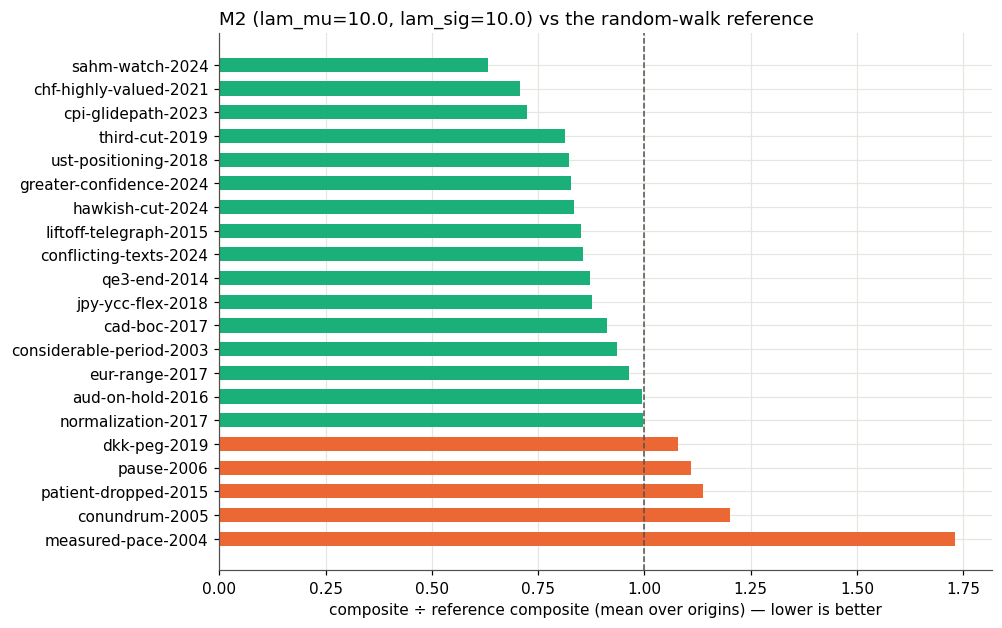

In [10]:
chosen = one(bt[bt.model != "M0"], LAM_MU, LAM_SIG)
per_unit = chosen.groupby("unit").agg(origins=("origin", "nunique"), n_train_max=("n_train", "max"),
                                      composite=("composite", "mean"), cov90=("cov90", "mean"),
                                      ratio_to_M0=("ratio", "mean"), beats_M0=("ratio", lambda r: (r < 1).mean()))
display(per_unit.round(3))

fig, ax = plt.subplots(figsize=(9, 5.6), layout="constrained")
pu = per_unit.sort_values("ratio_to_M0")
ax.barh(pu.index.str.replace("t2-F1-", ""), pu.ratio_to_M0,
        color=np.where(pu.ratio_to_M0 < 1, "#1baf7a", "#eb6834"), height=.6)
ax.axvline(1, color=INK2, lw=1, ls="--"); ax.invert_yaxis()
ax.set_xlabel("composite ÷ reference composite (mean over origins) — lower is better")
ax.set_title(f"M2 (lam_mu={LAM_MU}, lam_sig={LAM_SIG}) vs the random-walk reference"); plt.show()

## 5 — Final fit at each unit's as-of date, and save

Every cell is refitted on all rows available at its as-of, with the chosen penalties. Three files are
written: the backtest, the per-cell predictions, and the residual pools that carry the distribution's
shape. Notebook 04 needs only the last two.

In [11]:
pred_rows, pool_rows, coef_rows = [], [], []
for unit, cells in UNITS.items():
    for c in cells:
        f = m2_fit(c, c.asof, big(LAM_MU), big(LAM_SIG))
        pred_rows.append({"unit": unit, "asset": c.asset, "horizon_bd": c.h, "panel": c.panel, "freq": c.freq,
                          "target_type": "level", "value_unit": c.value_unit,
                          "asof": pd.Timestamp(c.asof), "steps_ahead": c.steps, "n_train": f["n_train"],
                          "anchor": f["anchor"], "mu": f["mu"], "sigma": f["sigma"],
                          "sigma_const": f["sigma_const"], "calib_c": f["calib_c"],
                          "lam_mu": LAM_MU, "lam_sig": LAM_SIG, "n_eps": len(f["eps"])})
        pool_rows.append(pd.DataFrame({"unit": unit, "asset": c.asset, "horizon_bd": c.h,
                                       "origin_date": f["eps"].index, "eps": f["eps"].to_numpy()}))
        for name, s in (("mu", f["beta"]), ("sigma", f["gamma"])):
            coef_rows += [{"unit": unit, "asset": c.asset, "horizon_bd": c.h, "model": name,
                           "feature": k, "coef": float(v)} for k, v in s.items()]

predictions = pd.DataFrame(pred_rows)
pools       = pd.concat(pool_rows, ignore_index=True)
coefs       = pd.DataFrame(coef_rows)

bt_out = bt.drop(columns=["hist"]).copy()
bt_out["lam_mu"]  = bt_out.lam_mu.astype(str)          # "M0" and floats share the column -> store as text
bt_out["lam_sig"] = bt_out.lam_sig.astype(str)
bt_out.to_parquet(DATA / "f1_backtest.parquet", index=False)
predictions.to_parquet(DATA / "f1_predictions.parquet", index=False)
pools.to_parquet(DATA / "f1_residual_pools.parquet", index=False)
coefs.to_parquet(DATA / "f1_coefficients.parquet", index=False)
(DATA / "f1_model_config.json").write_text(json.dumps({
    "model": "M2 ridge location-scale + empirical residual pool",
    "scope": "target_type == level",
    "lam_mu": LAM_MU, "lam_sig": LAM_SIG, "winsor": WINSOR,
    "sigma_clamp": [0.25, 4.0], "mu_clamp_sigmas": 3.0,
    "selection": {"rule": "argmin mean ratio on the tuning period",
                  "tuned_on": f"origins < {CUT.date()} with n_train >= {MIN_TRAIN_FOR_TUNING}",
                  "checked_on": f"origins >= {CUT.date()}",
                  "holdout_ratio_to_M0": float(one(hold, LAM_MU, LAM_SIG).ratio.mean()),
                  "holdout_cov90": float(one(hold, LAM_MU, LAM_SIG).cov90.mean())},
    "weights": list(WEIGHTS), "tail_levels": list(TAIL_LEVELS), "n_draws_backtest": N_BT,
}, indent=2) + "\n")

for p in sorted(DATA.glob("f1_*")): print(f"{p.name:<32} {p.stat().st_size/1e6:7.2f} MB")
print()
predictions.round({c: 4 for c in predictions.select_dtypes("number").columns})

f1_Xy.parquet                      11.11 MB
f1_backtest.parquet                 2.29 MB
f1_coefficients.parquet             0.01 MB
f1_columns.json                     0.00 MB
f1_model_config.json                0.00 MB
f1_predictions.parquet              0.01 MB
f1_residual_pools.parquet           1.56 MB
f1_submodel_features.csv            0.01 MB
f1_submodel_features.parquet        0.02 MB
f1_submodels.csv                    0.01 MB



,unit,asset,horizon_bd,panel,freq,target_type,value_unit,asof,steps_ahead,n_train,anchor,mu,sigma,sigma_const,calib_c,lam_mu,lam_sig,n_eps
0,t2-F1-aud-on-hold-2016,AUD,126,g10_fx_daily,daily,level,usd_per_aud,2016-11-01,126,3854,0.7659,0.0071,0.0722,0.0791,2.1363,10.0,10.0,3854
1,t2-F1-aud-on-hold-2016,AUD,189,g10_fx_daily,daily,level,usd_per_aud,2016-11-01,189,3791,0.7659,0.0115,0.0924,0.0959,2.2793,10.0,10.0,3791
2,t2-F1-cad-boc-2017,CAD,126,g10_fx_daily,daily,level,cad_per_usd,2017-07-12,126,4026,1.2768,-0.0098,0.0788,0.0787,2.0649,10.0,10.0,4026
3,t2-F1-cad-boc-2017,CAD,189,g10_fx_daily,daily,level,cad_per_usd,2017-07-12,189,3963,1.2768,-0.0133,0.0961,0.0962,2.1588,10.0,10.0,3963
4,t2-F1-chf-highly-valued-2021,CHF,126,g10_fx_daily,daily,level,chf_per_usd,2021-06-17,126,5006,0.9173,-0.0192,0.0604,0.0679,2.0225,10.0,10.0,5006
5,t2-F1-chf-highly-valued-2021,CHF,189,g10_fx_daily,daily,level,chf_per_usd,2021-06-17,189,4943,0.9173,-0.0287,0.0717,0.0783,2.0162,10.0,10.0,4943
6,t2-F1-conflicting-texts-2024,UST_10Y,126,rates_daily,daily,level,percent_per_annum,2024-06-12,126,5738,4.3100,-0.0257,0.6056,0.6088,1.9399,10.0,10.0,5738
7,t2-F1-conflicting-texts-2024,UST_10Y,189,rates_daily,daily,level,percent_per_annum,2024-06-12,189,5675,4.3100,-0.0292,0.6946,0.7015,1.8040,10.0,10.0,5675
8,t2-F1-considerable-period-2003,UST_10Y,126,rates_daily,daily,level,percent_per_annum,2003-08-12,126,525,4.3700,-0.5615,0.4450,0.4693,1.7751,10.0,10.0,525
9,t2-F1-considerable-period-2003,UST_10Y,189,rates_daily,daily,level,percent_per_annum,2003-08-12,189,462,4.3700,-0.7561,0.4654,0.4689,1.4050,10.0,10.0,462


## 6 — What notebook 04 will do with this

For each unit, draw 2,000 joint samples:

```
pick one origin_date at random  →  take that date's eps for EVERY cell of the unit
value = anchor + mu + sigma * eps
```

The shared date is what gives the draws their cross-horizon (and cross-asset) dependence — the
variogram term scores exactly that, and nothing else in the pipeline supplies it.